<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/PoisonDefense_HybridQC_PathMNIST_colab_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Poisoning Defense for Medical Image Classification (PathMNIST) — Colab Notebook
**Hybrid CNN → Variational Quantum Circuit (VQC) using PennyLane**  
**Threats:** training-time *label-flip poisoning* + *backdoor poisoning (3×3 patch, bottom-right, max intensity)*  
**Defenses:**  
- **Mechanism A:** poison-aware sanitization (warm-up embeddings → suspicion scores → per-class top-α filter)  
- **Mechanism B:** robust training objective (optional prototype consistency)  
- **Mechanism C:** quantum-head regularization via controlled quantum noise (ablation)

**Reporting:** images (clean vs triggered), stage-wise results (Baselines → A → A+B → A+B+C), Accuracy + Macro-AUROC, ASR.

**Locked settings (per user):** PathMNIST only • Acc + Macro-AUROC • 3×3 BR patch max intensity • poison rates 1/5/10 • 5 epochs • 3 seeds • PennyLane.


In [ ]:
# Cell 1 — Install & Imports
!pip -q install medmnist==2.2.3 pennylane==0.35.1 autoray==0.6.12 torch torchvision scikit-learn matplotlib pandas

import os, random, math, time, zipfile
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import roc_auc_score, accuracy_score

import medmnist
from medmnist import INFO

import pennylane as qml

print("torch:", torch.__version__)
print("pennylane:", qml.__version__)
print("medmnist:", medmnist.__version__)

torch: 2.10.0+cpu
pennylane: 0.35.1
medmnist: 2.2.3


In [ ]:

# Cell 2 — Reproducibility
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cpu


## Configuration (locked)

In [ ]:

# Cell 3 — Config
@dataclass
class Config:
    dataset: str = "pathmnist"
    batch_size: int = 256
    num_workers: int = 2
    epochs: int = 5
    seeds: Tuple[int, int, int] = (0, 1, 2)

    poison_rates: Tuple[float, float, float] = (0.01, 0.05, 0.10)
    poison_mode: str = "backdoor"  # backdoor first; later switch to "labelflip"
    target_class: int = 0

    trigger_size: int = 3
    trigger_loc: str = "bottom_right"
    trigger_value: float = 1.0

    latent_dim: int = 32
    q_in_dim: int = 4
    n_qubits: int = 4
    q_layers: int = 2

    # Mechanism A
    warmup_epochs: int = 1
    alpha_candidates: Tuple[float, ...] = (0.0, 0.01, 0.03, 0.05)
    clean_drop_tolerance: float = 0.01

    # Mechanism B
    use_prototypes: bool = True
    proto_weight: float = 0.05
    proto_conf_thresh: float = 0.8

    # Mechanism C
    use_quantum_noise: bool = True
    depolarize_p: float = 0.02

    out_dir: str = "outputs_pathmnist_poison_defense"

CFG = Config()
os.makedirs(CFG.out_dir, exist_ok=True)
print(CFG)


Config(dataset='pathmnist', batch_size=256, num_workers=2, epochs=5, seeds=(0, 1, 2), poison_rates=(0.01, 0.05, 0.1), poison_mode='backdoor', target_class=0, trigger_size=3, trigger_loc='bottom_right', trigger_value=1.0, latent_dim=32, q_in_dim=4, n_qubits=4, q_layers=2, warmup_epochs=1, alpha_candidates=(0.0, 0.01, 0.03, 0.05), clean_drop_tolerance=0.01, use_prototypes=True, proto_weight=0.05, proto_conf_thresh=0.8, use_quantum_noise=True, depolarize_p=0.02, out_dir='outputs_pathmnist_poison_defense')


In [ ]:
# Cell 4 — Load PathMNIST
info = INFO[CFG.dataset]
n_classes = len(info["label"])
DataClass = getattr(medmnist, info["python_class"])

train_data = DataClass(split="train", download=True)
val_data   = DataClass(split="val", download=True)
test_data  = DataClass(split="test", download=True)

def to_tensor(img):
    img_arr = np.array(img)
    if img_arr.ndim == 3 and img_arr.shape[0] in (1,3) and img_arr.shape[-1] not in (1,3):
        arr = img_arr
    elif img_arr.ndim == 2:
        arr = np.expand_dims(img_arr, 0)
    else:
        arr = np.transpose(img_arr, (2,0,1))
    return torch.from_numpy(arr.copy()).float() / 255.0

class WrappedMedMNIST(Dataset):
    def __init__(self, base): self.base = base
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        img, y = self.base[idx]
        x = to_tensor(img)
        # Bulletproof cast to integer to stop the NumPy warning spam
        y_val = y.item() if hasattr(y, 'item') else y[0] if isinstance(y, (np.ndarray, list)) else y
        return x, int(y_val), idx

train_ds = WrappedMedMNIST(train_data)
val_ds   = WrappedMedMNIST(val_data)
test_ds  = WrappedMedMNIST(test_data)

print("Sizes:", len(train_ds), len(val_ds), len(test_ds), "Classes:", n_classes)

Sizes: 89996 10004 7180 Classes: 9


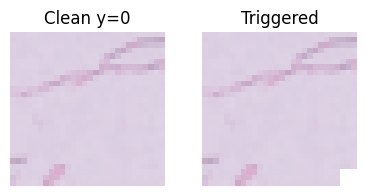

In [ ]:

# Cell 5 — Visualize clean vs triggered example
def add_patch_trigger(x: torch.Tensor, size: int, value: float, loc: str = "bottom_right") -> torch.Tensor:
    x2 = x.clone()
    C, H, W = x2.shape
    if loc == "bottom_right":
        r0, c0 = H - size, W - size
    else:
        r0, c0 = 0, 0
    x2[:, r0:r0+size, c0:c0+size] = value
    return x2

def show_clean_vs_triggered(ds: Dataset, idx: int):
    x, y, _ = ds[idx]
    xt = add_patch_trigger(x, CFG.trigger_size, CFG.trigger_value, CFG.trigger_loc)
    plt.figure(figsize=(4,2))
    plt.subplot(1,2,1); plt.imshow(x.permute(1,2,0)); plt.title(f"Clean y={y}"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(xt.permute(1,2,0)); plt.title("Triggered"); plt.axis("off")
    plt.tight_layout(); plt.show()

show_clean_vs_triggered(train_ds, 0)


In [ ]:

# Cell 6 — Poisoned dataset wrapper
def sample_poison_indices(n: int, poison_rate: float, seed: int) -> np.ndarray:
    rng = np.random.RandomState(seed)
    k = int(round(n * poison_rate))
    return rng.choice(np.arange(n), size=k, replace=False)

class PoisonedDataset(Dataset):
    def __init__(self, base: Dataset, poison_idx: np.ndarray, mode: str, target_class: int):
        self.base = base
        self.poison = set(poison_idx.tolist())
        assert mode in ("backdoor","labelflip")
        self.mode = mode
        self.target_class = target_class

    def __len__(self): return len(self.base)

    def __getitem__(self, idx):
        x, y, real_idx = self.base[idx]
        if idx in self.poison:
            if self.mode == "backdoor":
                x = add_patch_trigger(x, CFG.trigger_size, CFG.trigger_value, CFG.trigger_loc)
                y = self.target_class
            else:
                y = self.target_class if y != self.target_class else (y + 1) % n_classes
        return x, y, real_idx


## Models

In [ ]:

# Cell 7 — Classical encoder + baselines
class SmallCNNEncoder(nn.Module):
    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(128, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.fc(h)

class ClassicalBaseline(nn.Module):
    def __init__(self, latent_dim: int, n_classes: int):
        super().__init__()
        self.enc = SmallCNNEncoder(latent_dim)
        self.head = nn.Linear(latent_dim, n_classes)

    def forward(self, x):
        h = self.enc(x)
        return self.head(h), h


In [ ]:
# Cell 8 — Hybrid CNN→VQC model (PennyLane)
class QuantumHead(nn.Module):
    def __init__(self, n_qubits: int, q_layers: int, depolarize_p: float, use_noise: bool):
        super().__init__()
        self.n_qubits = n_qubits
        self.q_layers = q_layers
        self.depolarize_p = depolarize_p
        self.use_noise = use_noise

        weight_shapes = {"W": (q_layers, n_qubits, 3)}
        self.dev = qml.device("default.qubit", wires=n_qubits)

        # FIX: Changed diff_method to "backprop" to natively support batched inputs
        @qml.qnode(self.dev, interface="torch", diff_method="backprop")
        def circuit(inputs, W):
            for i in range(n_qubits):
                # Robust indexing for both batched and unbatched inputs
                feat = inputs[:, i] if len(inputs.shape) > 1 else inputs[i]
                qml.RY(feat, wires=i)

            for l in range(q_layers):
                for i in range(n_qubits):
                    qml.RX(W[l,i,0], wires=i)
                    qml.RY(W[l,i,1], wires=i)
                    qml.RZ(W[l,i,2], wires=i)
                for i in range(n_qubits):
                    qml.CNOT(wires=[i, (i+1) % n_qubits])

                # Mechanism C: controlled stochastic regularization
                if self.use_noise and self.training:
                    for i in range(n_qubits):
                        rx_noise = self.depolarize_p * (2.0 * torch.rand(1).item() - 1.0)
                        rz_noise = self.depolarize_p * (2.0 * torch.rand(1).item() - 1.0)
                        qml.RX(rx_noise, wires=i)
                        qml.RZ(rz_noise, wires=i)

            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.q_layer = qml.qnn.TorchLayer(circuit, weight_shapes)

    def forward(self, z):
        return self.q_layer(z)

class HybridQC(nn.Module):
    def __init__(self, latent_dim: int, q_in_dim: int, n_qubits: int, q_layers: int, n_classes: int,
                 depolarize_p: float, use_noise: bool):
        super().__init__()
        self.enc = SmallCNNEncoder(latent_dim)
        self.proj = nn.Linear(latent_dim, q_in_dim)
        self.qhead = QuantumHead(n_qubits, q_layers, depolarize_p, use_noise)
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x):
        h = self.enc(x)
        z = torch.tanh(self.proj(h)) * math.pi
        q = self.qhead(z)
        return self.head(q), h

## Metrics + Evaluation (Accuracy + Macro-AUROC, plus ASR for backdoor)

In [ ]:

# Cell 9 — Metrics
@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    logits_all, y_all = [], []
    for x, y, _ in loader:
        x = x.to(DEVICE)
        logits, _ = model(x)
        logits_all.append(logits.cpu())
        y_all.append(y)
    logits = torch.cat(logits_all, dim=0).numpy()
    y = torch.cat(y_all, dim=0).numpy()
    proba = F.softmax(torch.from_numpy(logits), dim=1).numpy()
    return proba, y

def macro_auroc(proba, y):
    try:
        return roc_auc_score(y, proba, multi_class="ovr", average="macro")
    except Exception:
        return float("nan")

def eval_clean(model, loader):
    proba, y = predict_proba(model, loader)
    acc = accuracy_score(y, np.argmax(proba, axis=1))
    auc = macro_auroc(proba, y)
    return {"acc": acc, "macro_auroc": auc}

@torch.no_grad()
def eval_asr(model, loader, target_class: int):
    model.eval()
    total, success = 0, 0
    for x, y, _ in loader:
        mask = (y != target_class)
        if mask.sum().item() == 0:
            continue
        x = x[mask]
        xt = torch.stack([add_patch_trigger(img, CFG.trigger_size, CFG.trigger_value, CFG.trigger_loc) for img in x], dim=0).to(DEVICE)
        logits, _ = model(xt)
        pred = torch.argmax(logits, dim=1).cpu()
        success += (pred == target_class).sum().item()
        total += pred.numel()
    return success / max(1, total)


## Mechanism A: Warm-up scoring + per-class top-α filtering

In [ ]:

# Cell 10 — Warm-up + suspicion scoring
def train_warmup(seed: int, poisoned_train: Dataset):
    seed_everything(seed)
    model = ClassicalBaseline(CFG.latent_dim, n_classes).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loader = DataLoader(poisoned_train, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)

    model.train()
    for _ in range(CFG.warmup_epochs):
        for x, y, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, _ = model(x)
            loss = F.cross_entropy(logits, y)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

@torch.no_grad()
def suspicion_scores(warm_model, poisoned_train: Dataset):
    warm_model.eval()
    loader = DataLoader(poisoned_train, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)

    feats, labels, losses = [], [], []
    for x, y, _ in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits, h = warm_model(x)
        per_loss = F.cross_entropy(logits, y, reduction="none")
        feats.append(h.cpu()); labels.append(y.cpu()); losses.append(per_loss.cpu())

    feats = torch.cat(feats).numpy()
    labels = torch.cat(labels).numpy()
    losses = torch.cat(losses).numpy()

    centroids = np.zeros((n_classes, feats.shape[1]), dtype=np.float32)
    for c in range(n_classes):
        idx = np.where(labels == c)[0]
        if len(idx) > 0:
            centroids[c] = feats[idx].mean(axis=0)

    dists = np.array([np.linalg.norm(feats[i] - centroids[labels[i]]) for i in range(len(labels))], dtype=np.float32)

    loss_n = (losses - losses.min()) / (losses.max() - losses.min() + 1e-8)
    dist_n = (dists - dists.min()) / (dists.max() - dists.min() + 1e-8)
    scores = 0.5 * loss_n + 0.5 * dist_n
    return scores.astype(np.float32), labels.astype(np.int64)

def filter_top_alpha(scores, labels, alpha: float):
    keep = []
    for c in range(n_classes):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue
        k = int(np.ceil(alpha * len(idx)))
        order = idx[np.argsort(scores[idx])[::-1]]
        remove = set(order[:k].tolist())
        keep.extend([i for i in idx.tolist() if i not in remove])
    return np.array(sorted(keep), dtype=np.int64)


## Mechanism B: Prototype consistency (optional)

In [ ]:

# Cell 11 — Prototype bank
class PrototypeBank:
    def __init__(self, dim: int, momentum: float = 0.9):
        self.proto = torch.zeros(n_classes, dim)
        self.init = torch.zeros(n_classes, dtype=torch.bool)
        self.m = momentum

    @torch.no_grad()
    def update(self, h, yhat, conf, thresh):
        for c in range(n_classes):
            mask = (yhat == c) & (conf >= thresh)
            if mask.sum().item() == 0:
                continue
            mean = h[mask].mean(dim=0).cpu()
            if not self.init[c]:
                self.proto[c] = mean; self.init[c] = True
            else:
                self.proto[c] = self.m * self.proto[c] + (1-self.m) * mean

    def get(self, y):
        return self.proto[y.cpu()].to(y.device)


In [ ]:

# Cell 12 — Training loop (A/B/C stages)
def train_model(model, train_loader, val_loader, seed: int, use_prototypes: bool, proto_weight: float):
    seed_everything(seed)
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    proto_bank = PrototypeBank(CFG.latent_dim) if use_prototypes else None
    hist = {"val_acc": [], "val_auroc": [], "val_asr": []}

    for ep in range(CFG.epochs):
        model.train()
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, h = model(x)
            loss = F.cross_entropy(logits, y)

            if use_prototypes:
                with torch.no_grad():
                    p = F.softmax(logits, dim=1)
                    conf, yhat = torch.max(p, dim=1)
                    proto_bank.update(h, yhat, conf, CFG.proto_conf_thresh)
                proto_target = proto_bank.get(y)
                loss = loss + proto_weight * F.mse_loss(h, proto_target)

            opt.zero_grad(); loss.backward(); opt.step()

        clean = eval_clean(model, val_loader)
        asr = eval_asr(model, val_loader, CFG.target_class)
        hist["val_acc"].append(clean["acc"])
        hist["val_auroc"].append(clean["macro_auroc"])
        hist["val_asr"].append(asr)
        print(f"Epoch {ep+1}/{CFG.epochs} | val_acc={clean['acc']:.4f} | val_auroc={clean['macro_auroc']:.4f} | val_ASR={asr:.4f}")

    return hist, model


In [ ]:

# Cell 13 — Experiment runner for one poison rate + seed
val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)

def run_one(poison_rate: float, seed: int):
    seed_everything(seed)
    poison_idx = sample_poison_indices(len(train_ds), poison_rate, seed=seed+123)
    poisoned_train = PoisonedDataset(train_ds, poison_idx, CFG.poison_mode, CFG.target_class)

    # Mechanism A: warm-up + score + select alpha by validation (simple rule: pick alpha that lowers ASR with minimal clean drop)
    warm = train_warmup(seed, poisoned_train)
    scores, labels = suspicion_scores(warm, poisoned_train)

    # Quick base val acc for constraint (proxy)
    proxy = ClassicalBaseline(CFG.latent_dim, n_classes).to(DEVICE)
    opt = torch.optim.Adam(proxy.parameters(), lr=1e-3)
    proxy_loader = DataLoader(poisoned_train, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
    proxy.train()
    for x, y, _ in proxy_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits, _ = proxy(x)
        loss = F.cross_entropy(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        break
    base_acc = eval_clean(proxy, val_loader)["acc"]

    best_alpha = 0.0
    best_asr = 1e9
    for a in CFG.alpha_candidates:
        keep_idx = filter_top_alpha(scores, labels, a)
        filt_train = Subset(poisoned_train, keep_idx.tolist())
        # quick proxy training 1 step for alpha selection
        proxy2 = ClassicalBaseline(CFG.latent_dim, n_classes).to(DEVICE)
        opt2 = torch.optim.Adam(proxy2.parameters(), lr=1e-3)
        ldr = DataLoader(filt_train, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
        proxy2.train()
        for x, y, _ in ldr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, _ = proxy2(x)
            loss = F.cross_entropy(logits, y)
            opt2.zero_grad(); loss.backward(); opt2.step()
            break
        clean = eval_clean(proxy2, val_loader)
        asr = eval_asr(proxy2, val_loader, CFG.target_class)
        if clean["acc"] >= base_acc - CFG.clean_drop_tolerance and asr < best_asr:
            best_asr = asr
            best_alpha = a

    keep_idx = filter_top_alpha(scores, labels, best_alpha)
    filtered_train = Subset(poisoned_train, keep_idx.tolist())

    train_loader_poisoned = DataLoader(poisoned_train, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
    train_loader_filtered = DataLoader(filtered_train, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)

    results = {}

    # Classical baseline
    m1 = ClassicalBaseline(CFG.latent_dim, n_classes)
    h1, _ = train_model(m1, train_loader_poisoned, val_loader, seed, use_prototypes=False, proto_weight=0.0)
    results["classical_baseline"] = h1

    # Hybrid baseline (no noise)
    m2 = HybridQC(CFG.latent_dim, CFG.q_in_dim, CFG.n_qubits, CFG.q_layers, n_classes, CFG.depolarize_p, use_noise=False)
    h2, _ = train_model(m2, train_loader_poisoned, val_loader, seed, use_prototypes=False, proto_weight=0.0)
    results["hybrid_baseline"] = h2

    # Hybrid + A
    m3 = HybridQC(CFG.latent_dim, CFG.q_in_dim, CFG.n_qubits, CFG.q_layers, n_classes, CFG.depolarize_p, use_noise=False)
    h3, _ = train_model(m3, train_loader_filtered, val_loader, seed, use_prototypes=False, proto_weight=0.0)
    results["hybrid_A"] = h3

    # Hybrid + A+B
    m4 = HybridQC(CFG.latent_dim, CFG.q_in_dim, CFG.n_qubits, CFG.q_layers, n_classes, CFG.depolarize_p, use_noise=False)
    h4, _ = train_model(m4, train_loader_filtered, val_loader, seed, use_prototypes=CFG.use_prototypes, proto_weight=CFG.proto_weight)
    results["hybrid_AB"] = h4

    # Hybrid + A+B+C
    m5 = HybridQC(CFG.latent_dim, CFG.q_in_dim, CFG.n_qubits, CFG.q_layers, n_classes, CFG.depolarize_p, use_noise=CFG.use_quantum_noise)
    h5, _ = train_model(m5, train_loader_filtered, val_loader, seed, use_prototypes=CFG.use_prototypes, proto_weight=CFG.proto_weight)
    results["hybrid_ABC"] = h5

    meta = {"poison_rate": poison_rate, "seed": seed, "best_alpha": best_alpha, "poisoned_count": len(poison_idx), "kept": len(keep_idx)}
    return meta, results


In [ ]:

# Cell 14 — Run grid (poison rates × 3 seeds)
all_rows = []
for pr in CFG.poison_rates:
    for sd in CFG.seeds:
        print("\n" + "="*80)
        print(f"Running poison_rate={pr}, seed={sd}")
        meta, res = run_one(pr, sd)
        for variant, h in res.items():
            all_rows.append({
                **meta,
                "variant": variant,
                "val_acc": h["val_acc"][-1],
                "val_auroc": h["val_auroc"][-1],
                "val_asr": h["val_asr"][-1],
            })

df = pd.DataFrame(all_rows)
display(df)
df.to_csv(os.path.join(CFG.out_dir, "results.csv"), index=False)
print("Saved:", os.path.join(CFG.out_dir, "results.csv"))



Running poison_rate=0.01, seed=0
Epoch 1/5 | val_acc=0.6119 | val_auroc=0.9196 | val_ASR=0.0407
Epoch 2/5 | val_acc=0.6394 | val_auroc=0.9326 | val_ASR=0.0360
Epoch 3/5 | val_acc=0.7111 | val_auroc=0.9532 | val_ASR=0.0134
Epoch 4/5 | val_acc=0.7364 | val_auroc=0.9604 | val_ASR=0.0187
Epoch 5/5 | val_acc=0.7652 | val_auroc=0.9691 | val_ASR=0.0110
Epoch 1/5 | val_acc=0.4659 | val_auroc=0.8640 | val_ASR=0.1165
Epoch 2/5 | val_acc=0.5219 | val_auroc=0.9055 | val_ASR=0.1118
Epoch 3/5 | val_acc=0.6436 | val_auroc=0.9296 | val_ASR=0.0481
Epoch 4/5 | val_acc=0.6503 | val_auroc=0.9255 | val_ASR=0.0452
Epoch 5/5 | val_acc=0.7152 | val_auroc=0.9509 | val_ASR=0.0288
Epoch 1/5 | val_acc=0.4659 | val_auroc=0.8640 | val_ASR=0.1165
Epoch 2/5 | val_acc=0.5219 | val_auroc=0.9055 | val_ASR=0.1118
Epoch 3/5 | val_acc=0.6436 | val_auroc=0.9296 | val_ASR=0.0481
Epoch 4/5 | val_acc=0.6503 | val_auroc=0.9255 | val_ASR=0.0452
Epoch 5/5 | val_acc=0.7152 | val_auroc=0.9509 | val_ASR=0.0288
Epoch 1/5 | val_acc=0

,poison_rate,seed,best_alpha,poisoned_count,kept,variant,val_acc,val_auroc,val_asr
0,0.01,0,0.00,900,89996,classical_baseline,0.765194,0.969091,0.011045
1,0.01,0,0.00,900,89996,hybrid_baseline,0.715214,0.950893,0.028785
2,0.01,0,0.00,900,89996,hybrid_A,0.715214,0.950893,0.028785
3,0.01,0,0.00,900,89996,hybrid_AB,0.736705,0.957035,0.020640
4,0.01,0,0.00,900,89996,hybrid_ABC,0.730908,0.951906,0.022202
5,0.01,1,0.01,900,89090,classical_baseline,0.720612,0.958406,0.020752
6,0.01,1,0.01,900,89090,hybrid_baseline,0.676130,0.943901,0.032578
7,0.01,1,0.01,900,89090,hybrid_A,0.632847,0.934784,0.016735
8,0.01,1,0.01,900,89090,hybrid_AB,0.661435,0.941871,0.079215
9,0.01,1,0.01,900,89090,hybrid_ABC,0.486106,0.881132,0.353899


Saved: outputs_pathmnist_poison_defense/results.csv


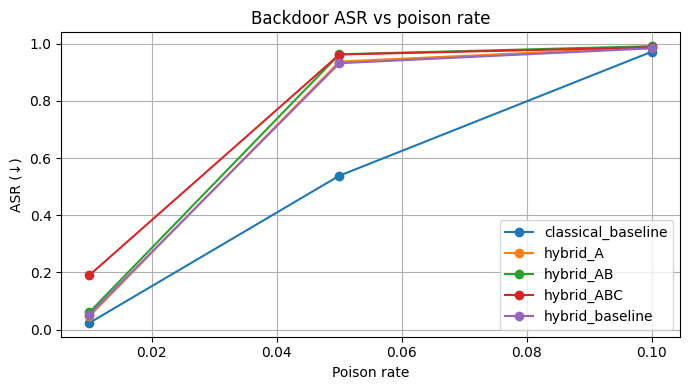

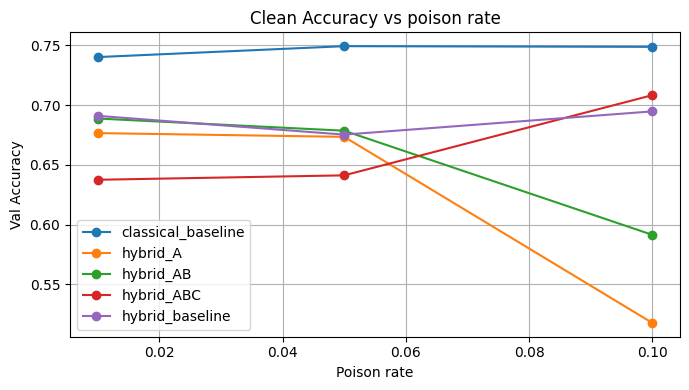

In [ ]:

# Cell 15 — Plot results
plt.figure(figsize=(7,4))
for v in sorted(df["variant"].unique()):
    sub = df[df["variant"]==v].groupby("poison_rate")["val_asr"].mean()
    plt.plot(sub.index, sub.values, marker="o", label=v)
plt.xlabel("Poison rate"); plt.ylabel("ASR (↓)"); plt.title("Backdoor ASR vs poison rate")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(CFG.out_dir, "asr_vs_poison_rate.png"), dpi=200)
plt.show()

plt.figure(figsize=(7,4))
for v in sorted(df["variant"].unique()):
    sub = df[df["variant"]==v].groupby("poison_rate")["val_acc"].mean()
    plt.plot(sub.index, sub.values, marker="o", label=v)
plt.xlabel("Poison rate"); plt.ylabel("Val Accuracy"); plt.title("Clean Accuracy vs poison rate")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(CFG.out_dir, "acc_vs_poison_rate.png"), dpi=200)
plt.show()


In [ ]:

# Cell 16 — Zip artifacts
zip_path = os.path.join(CFG.out_dir, "artifacts.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for f in os.listdir(CFG.out_dir):
        if f.endswith((".csv",".png")):
            z.write(os.path.join(CFG.out_dir, f), arcname=f)
print("ZIP:", zip_path)


ZIP: outputs_pathmnist_poison_defense/artifacts.zip
